# Projeto AURORA — Sistema de Verificação de Decolagem

**Atividade integradora (PBL) — FIAP**

Este notebook reúne os itens 1.1 a 1.5 da atividade. Ele é executável de ponta a
ponta: basta rodar as células na ordem (menu *Run > Run All Cells*).

| Item | Conteúdo |
| :--- | :--- |
| 1.1 | Organização e descrição da telemetria |
| 1.2 | Algoritmo de verificação |
| 1.3 | Script em Python |
| 1.4 | Análise energética |
| 1.5 | Análise assistida por IA |

Depois dos cinco itens, o notebook lê os **12 cenários coletados** e as **8 missões
simuladas** que o programa gravou em disco, e monta as tabelas comparativas. O
item 1.6, a reflexão crítica, está no relatório em PDF.

> **Sobre a estrutura do projeto:** a versão interativa do programa, que lê os
> dados digitados pelo operador e segue para a missão Terra → Marte, está em
> `scripts/main.py`. Neste notebook os dados são definidos em variáveis para que a
> execução seja reprodutível e não dependa de digitação. As células de código
> repetem a lógica do `main.py` na mesma ordem e com os mesmos nomes.

---
## 1.1 Organização e descrição da telemetria

O operador informa cinco dados. A integridade é o sexto indicador, calculado pelo sistema.

| Parâmetro | Origem | Unidade | Faixa segura |
| :--- | :--- | :--- | :--- |
| Temperatura interna | Telemetria informada | °C | 15 a 30 |
| Temperatura externa | Telemetria informada | °C | -10 a 45 |
| Pressão dos tanques | Telemetria informada | psi | 450 a 550 |
| Nível de energia | Telemetria informada | % | 80 a 100 |
| Módulos críticos | Estado informado | S/N | online |
| Integridade operacional estimada | Calculada automaticamente | 0/1 | 1 |

### Critérios da integridade

O sistema atribui `1` (preservada no modelo) quando as duas temperaturas e a pressão
estão nas faixas seguras, incluindo os limites, e os módulos críticos estão online.
Se qualquer critério falhar, atribui `0` (comprometida no modelo), explica os motivos
e bloqueia a decolagem. Energia e reserva recebem uma avaliação própria.

A integridade é uma estimativa operacional da simulação. Sem sensores de danos no
casco, estes dados não comprovam a integridade física da estrutura. Os alertas de
correlação continuam sendo avaliados pela análise assistida.

O programa interativo rejeita entradas não numéricas, NaN e infinito, e aceita
apenas S/N para os módulos. A integridade nunca é digitada pelo operador.


---
## 1.2 Algoritmo de verificação

O algoritmo trabalha em três fases e termina numa decisão que pode ser humana:

**FASE 1 — Verificações de segurança.** As seis verificações são executadas
**sempre**, e cada uma pode desligar a chave `decolagem_autorizada`. Elas não
abortam em cascata: o operador precisa enxergar todos os problemas de uma vez, e
não descobrir o próximo defeito só na tentativa seguinte.

**FASE 2 — Análise assistida por IA.** Cruza os parâmetros entre si, procurando
discrepâncias que nenhuma verificação isolada consegue detectar. Roda mesmo
quando uma verificação já desligou a chave: é ela que faz a triagem final.

**FASE 3 — Veredito e classificação.**

| Chave | Alertas | Classificação | O que acontece |
| :--- | :--- | :--- | :--- |
| Desligada | — | **HORRÍVEL** | decolagem abortada |
| Ligada | 1 ou mais | **MÉDIO** | decolagem **em espera**: a decisão passa para o capitão |
| Ligada | nenhum | **ÓTIMO** | decolagem autorizada |

**Decisão do capitão.** No cenário MÉDIO o programa lista os alertas e pergunta
se deseja seguir. Só a resposta `s` mantém a decolagem; qualquer outra aborta. O
capitão funciona como mais uma verificação: ele pode desligar a chave, nunca
ligar uma que a IA desligou.

Em pseudocódigo:

```
ler cinco dados de telemetria
calcular integridade a partir de temperaturas, pressão e módulos
chave = ligada
para cada uma das 6 verificações:        (fase 1)
    fora da faixa? → registra erro, chave = desligada
grupo 1 da IA: dado impossível? → crítico, chave = desligada
grupos 2, 3 e 4 da IA: combinação de risco? → alerta      (fase 2)
se chave desligada  → HORRÍVEL → abortada                   (fase 3)
senão se há alertas → MÉDIO    → em espera → capitão decide
senão               → ÓTIMO    → autorizada
```

> O fluxograma completo, em formato Mermaid, está no `README.md` do repositório
> (seção "Como funciona"), onde o GitHub o renderiza graficamente.

---
## 1.3 Script em Python

### Constantes do projeto

Como no `main.py`, todas as regras da nave ficam em constantes no topo. Para
mudar uma faixa segura, muda-se aqui, e não no meio do código.

In [1]:
# --- A NAVE ---
CAPACIDADE_TOTAL = 1000.0   # kWh - capacidade total da bateria
CONSUMO_DECOLAGEM = 300.0   # kWh - consumo estimado na fase de decolagem
PERDAS = 0.08               # 8% da energia armazenada se perde (conversao do inversor + aquecimento)
RESERVA_MINIMA = 0.10       # 10% da capacidade deve sobrar como reserva de pouso

# --- FAIXAS SEGURAS DA TELEMETRIA ---
TEMP_INTERNA_MIN = 15.0     # C
TEMP_INTERNA_MAX = 30.0     # C
TEMP_EXTERNA_MIN = -10.0    # C
TEMP_EXTERNA_MAX = 45.0     # C
PRESSAO_MIN = 450.0         # psi
PRESSAO_MAX = 550.0         # psi
ENERGIA_MINIMA = 80.0       # % - abaixo disso a decolagem e abortada

# --- LIMIARES DA ANALISE ASSISTIDA POR IA ---
TEMP_EXTERNA_FRIA = 0.0         # C - abaixo disso a bateria de litio perde capacidade utilizavel
ENERGIA_CONFORTAVEL = 90.0      # % - energia abaixo disso no frio gera alerta
PRESSAO_ALTA = 520.0            # psi - pressao acima disso com cabine quente gera alerta
TEMP_INTERNA_QUENTE = 27.0      # C - cabine quente (lei dos gases)
TEMP_INTERNA_ALERTA = 28.0      # C - proxima do teto, e os motores ainda vao aquecer
DIFERENCIAL_TERMICO_MAX = 35.0  # C - diferenca interna/externa que sugere falha de isolamento
FRONTEIRA_ENERGIA = 2.0         # % - energia entre 80 e 82 esta no limiar (incerteza tipica do sensor)
FRONTEIRA_PRESSAO = 10.0        # psi - faixa de "fronteira" junto aos limites 450 e 550
AUTONOMIA_BAIXA = 20.0          # % - reserva pos-decolagem abaixo disso e pouca folga

# A TELEMETRIA "PERFEITA" QUE LEVANTA SUSPEITA DE VALOR PADRAO DE FABRICA:
NOMINAL_TEMP_INTERNA = 22.0
NOMINAL_TEMP_EXTERNA = 25.0
NOMINAL_PRESSAO = 500.0
NOMINAL_ENERGIA = 100.0

print("Constantes carregadas.")

Constantes carregadas.


### Faixas seguras adotadas

A tabela abaixo é impressa **a partir das constantes**, e não digitada à mão, para
que o documento nunca discorde do código.

In [2]:
print("{:<24} {:>10} {:>10}  {}".format("PARAMETRO", "MINIMO", "MAXIMO", "UNIDADE"))
print("-" * 58)
print("{:<24} {:>10.1f} {:>10.1f}  {}".format("Temperatura interna", TEMP_INTERNA_MIN, TEMP_INTERNA_MAX, "C"))
print("{:<24} {:>10.1f} {:>10.1f}  {}".format("Temperatura externa", TEMP_EXTERNA_MIN, TEMP_EXTERNA_MAX, "C"))
print("{:<24} {:>10} {:>10}  {}".format("Integridade calculada", "1", "1", "0/1 derivado da telemetria"))
print("{:<24} {:>10.1f} {:>10.1f}  {}".format("Pressao dos tanques", PRESSAO_MIN, PRESSAO_MAX, "psi"))
print("{:<24} {:>10.1f} {:>10.1f}  {}".format("Nivel de energia", ENERGIA_MINIMA, 100.0, "%"))
print("{:<24} {:>10} {:>10}  {}".format("Modulos criticos", "online", "online", "binario"))
print("")
print("Bateria de {:.0f} kWh, consumo de {:.0f} kWh na decolagem, perdas de {:.0f}%, reserva de {:.0f}%.".format(
    CAPACIDADE_TOTAL, CONSUMO_DECOLAGEM, PERDAS * 100, RESERVA_MINIMA * 100))

PARAMETRO                    MINIMO     MAXIMO  UNIDADE
----------------------------------------------------------
Temperatura interna            15.0       30.0  C
Temperatura externa           -10.0       45.0  C
Integridade calculada             1          1  0/1 derivado da telemetria
Pressao dos tanques           450.0      550.0  psi
Nivel de energia               80.0      100.0  %
Modulos criticos             online     online  binario

Bateria de 1000 kWh, consumo de 300 kWh na decolagem, perdas de 8%, reserva de 10%.


### Leitura dos dados

No programa interativo (`scripts/main.py`) esta etapa usa `input()`. Aqui os
valores são fixos para tornar a execução reprodutível. Os valores abaixo são os
do **cenário 06** da coleta (capitã Aline), escolhido porque cai em MÉDIO e
exercita o caminho inteiro, inclusive a decisão do capitão.

Altere os valores desta célula para simular outros cenários.

In [3]:
# --- TELEMETRIA RECEBIDA ---
# No programa interativo estes valores vem de input(); aqui sao fixos.
nome_capitao = "Aline"
temp_interna = 29.0      # graus Celsius
temp_externa = -8.0      # graus Celsius
pressao_tanques = 535.0  # psi
energia = 93.0           # porcentagem da bateria
modulos_online = True    # todos os modulos criticos online

# INTEGRIDADE OPERACIONAL ESTIMADA, DERIVADA DA TELEMETRIA.
# ESTES CRITERIOS DIDATICOS NAO SUBSTITUEM SENSORES DE DANOS NO CASCO.
# ENERGIA E RESERVA SAO AVALIADAS SEPARADAMENTE NA ETAPA ENERGETICA.
motivos_integridade = []
if not TEMP_INTERNA_MIN <= temp_interna <= TEMP_INTERNA_MAX:
    motivos_integridade.append("temperatura interna fora da faixa segura")
if not TEMP_EXTERNA_MIN <= temp_externa <= TEMP_EXTERNA_MAX:
    motivos_integridade.append("temperatura externa fora da faixa segura")
if not PRESSAO_MIN <= pressao_tanques <= PRESSAO_MAX:
    motivos_integridade.append("pressão dos tanques fora da faixa segura")
if not modulos_online:
    motivos_integridade.append("módulos críticos offline")
integridade = int(not motivos_integridade)
if motivos_integridade:
    diagnostico_integridade = "; ".join(motivos_integridade)
else:
    diagnostico_integridade = "temperaturas e pressão nas faixas seguras; módulos críticos online"

# A CHAVE COMECA LIGADA E SO PODE SER DESLIGADA PELAS VERIFICACOES
decolagem_autorizada = True

if integridade == 1:
    integridade_texto = "1 (Preservada no modelo)"
else:
    integridade_texto = "0 (Comprometida no modelo)"

if modulos_online:
    modulos_texto = "SIM"
else:
    modulos_texto = "NAO"

print("=" * 62)
print("TELEMETRIA E DIAGNOSTICO AUTOMATICO")
print("=" * 62)
print("  Capitao             : {}".format(nome_capitao))
print("  Temperatura interna : {:.1f} C".format(temp_interna))
print("  Temperatura externa : {:.1f} C".format(temp_externa))
print("  Integridade calculada: {}".format(integridade_texto))
print("  Diagnostico         : {}".format(diagnostico_integridade))
print("  Pressao dos tanques : {:.1f} psi".format(pressao_tanques))
print("  Energia             : {:.1f} %".format(energia))
print("  Modulos online      : {}".format(modulos_texto))

TELEMETRIA E DIAGNOSTICO AUTOMATICO
  Capitao             : Aline
  Temperatura interna : 29.0 C
  Temperatura externa : -8.0 C
  Integridade calculada: 1 (Preservada no modelo)
  Diagnostico         : temperaturas e pressão nas faixas seguras; módulos críticos online
  Pressao dos tanques : 535.0 psi
  Energia             : 93.0 %
  Modulos online      : SIM


### Diagnóstico explicado

A integridade foi calculada na célula anterior. A lista de motivos permite
identificar cada critério reprovado. Para experimentar uma falha, altere a pressão
para `560` ou os módulos para `False` e execute novamente todas as células.


In [4]:
print("Integridade calculada automaticamente:", integridade)
print("Motivo:", diagnostico_integridade)
assert integridade in (0, 1)
assert integridade == int(not motivos_integridade)


Integridade calculada automaticamente: 1
Motivo: temperaturas e pressão nas faixas seguras; módulos críticos online


### Execução das verificações

Todos os parâmetros são avaliados. A integridade é um resultado calculado;
qualquer critério reprovado bloqueia a decolagem, mesmo que o capitão queira seguir.


In [5]:
erros_seguranca = []  # MOTIVOS QUE O SCRIPT PERSISTE NO TXT
print("=" * 62)
print("VERIFICACOES DE SEGURANCA")
print("=" * 62)

# Verificacao 1 - TEMPERATURA INTERNA E EXTERNA
if temp_interna > TEMP_INTERNA_MAX or temp_interna < TEMP_INTERNA_MIN:
    print("Erro: Temperatura Interna fora do range!")
    erros_seguranca.append("Erro: Temperatura Interna fora do range!")
    decolagem_autorizada = False
else:
    print("Temperatura Interna: OK")

if temp_externa > TEMP_EXTERNA_MAX or temp_externa < TEMP_EXTERNA_MIN:
    print("Erro: Temperatura Externa fora do range!")
    erros_seguranca.append("Erro: Temperatura Externa fora do range!")
    decolagem_autorizada = False
else:
    print("Temperatura Externa: OK")

# Verificacao 2 - INTEGRIDADE
if integridade != 1:
    print("Erro: Integridade operacional comprometida no modelo!")
    erros_seguranca.append("Erro: Integridade operacional comprometida no modelo!")
    decolagem_autorizada = False
else:
    print("Integridade operacional: Preservada no modelo")

# Verificacao 3 - PRESSAO DOS TANQUES
if pressao_tanques < PRESSAO_MIN or pressao_tanques > PRESSAO_MAX:
    print("Erro: Pressão dos tanques fora do range!")
    erros_seguranca.append("Erro: Pressão dos tanques fora do range!")
    decolagem_autorizada = False
else:
    print("Pressão dos Tanques: OK")

VERIFICACOES DE SEGURANCA
Temperatura Interna: OK
Temperatura Externa: OK
Integridade operacional: Preservada no modelo
Pressão dos Tanques: OK


---
## 1.4 Análise energética

O nível de energia é informado em **porcentagem**, mas a autonomia precisa ser
calculada em **kWh**. O cálculo segue os termos do material da disciplina, em
quatro passos:

1. **Energia disponível**: converter a carga atual de % para kWh
2. **Energia perdida**: a parcela da energia disponível que o sistema não aproveita
3. **Energia útil**: a energia disponível depois de descontar as perdas
4. **Energia restante**: a energia útil menos o consumo estimado da decolagem

As perdas são aplicadas **sobre a energia armazenada** (conversão do inversor e
aquecimento), e o consumo da decolagem é descontado depois, da energia útil.

| Termo | Cálculo | Exemplo (carga 80 %) |
| :--- | :--- | --: |
| Energia disponível (kWh) | capacidade total × carga atual | 800 |
| Energia perdida (kWh) | energia disponível × perdas (8 %) | 64 |
| Energia útil (kWh) | energia disponível − energia perdida | 736 |
| Energia restante (kWh) | energia útil − consumo da decolagem (300 kWh) | 436 |

In [6]:
energia_disponivel = CAPACIDADE_TOTAL * (energia / 100)            # ex: 1000 * 0.80 = 800 kWh
energia_perdida = energia_disponivel * PERDAS                       # ex: 800 * 0.08  = 64 kWh
energia_util = energia_disponivel - energia_perdida                 # ex: 800 - 64    = 736 kWh
energia_restante = energia_util - CONSUMO_DECOLAGEM                 # ex: 736 - 300   = 436 kWh
autonomia_restante = (energia_restante / CAPACIDADE_TOTAL) * 100   # a mesma sobra, em % da bateria

print("=" * 62)
print("ANALISE ENERGETICA")
print("=" * 62)
print("  Capacidade total            : {:.1f} kWh".format(CAPACIDADE_TOTAL))
print("  Carga atual                 : {:.1f} %".format(energia))
print("  Energia disponivel          : {:.1f} kWh".format(energia_disponivel))
print("  Perdas energeticas          : {:.0f} %".format(PERDAS * 100))
print("  Energia perdida             : {:.1f} kWh".format(energia_perdida))
print("  Energia util                : {:.1f} kWh".format(energia_util))
print("  Consumo na decolagem        : {:.1f} kWh".format(CONSUMO_DECOLAGEM))
print("  Energia apos a decolagem    : {:.1f} kWh ({:.1f}% da bateria)".format(energia_restante, autonomia_restante))
if energia_restante > 0:
    print("  Resultado: energia suficiente para a decolagem.")
else:
    print("  Resultado: energia insuficiente para a decolagem.")

ANALISE ENERGETICA
  Capacidade total            : 1000.0 kWh
  Carga atual                 : 93.0 %
  Energia disponivel          : 930.0 kWh
  Perdas energeticas          : 8 %
  Energia perdida             : 74.4 kWh
  Energia util                : 855.6 kWh
  Consumo na decolagem        : 300.0 kWh
  Energia apos a decolagem    : 555.6 kWh (55.6% da bateria)
  Resultado: energia suficiente para a decolagem.


### Verificação de energia e de reserva

A verificação de reserva só faz sentido se a energia mínima já tiver passado — por
isso é um `elif`, e não um `if` independente.

Dois registros que valem a leitura. Primeiro: com consumo de 300 kWh e 8% de
perdas, a energia mínima *matemática* para decolar seria de apenas **32,6%** de
carga (326 kWh disponíveis viram 300 kWh úteis). O limite de 80% não vem do
consumo da decolagem — ele existe para garantir autonomia **depois** dela.

Segundo: com as constantes atuais o ramo da reserva **nunca dispara**, porque 80%
de carga já deixa 43,6% de sobra, muito acima dos 10% exigidos. Ele fica no código
como proteção: passa a valer se o consumo da decolagem subir ou o mínimo de
energia descer.

In [7]:
# Verificacao 4 - ENERGIA
if energia < ENERGIA_MINIMA:
    print("Erro: Energia insuficiente!")
    erros_seguranca.append("Erro: Energia insuficiente!")
    decolagem_autorizada = False
elif energia_restante < CAPACIDADE_TOTAL * RESERVA_MINIMA:
    # DECOLA MAS NAO SOBRA CARGA PARA MANOBRA/POUSO -> TAMBEM ABORTA.
    # PROTECAO: COM AS CONSTANTES ATUAIS ESTE RAMO NUNCA RODA (80% JA DEIXA 43,6% DE SOBRA).
    print("Erro: Reserva pós-decolagem insuficiente ({:.1f} kWh)!".format(energia_restante))
    erros_seguranca.append("Erro: Reserva pós-decolagem insuficiente ({:.1f} kWh)!".format(energia_restante))
    decolagem_autorizada = False
else:
    print("Energia: OK")

# Verificacao 5 - MODULOS ONLINE
if not modulos_online:
    print("Erro: Módulos offline!")
    erros_seguranca.append("Erro: Módulos offline!")
    decolagem_autorizada = False
else:
    print("Módulos: OK")

Energia: OK
Módulos: OK


---
## 1.5 Análise assistida por IA

As verificações acima olham cada parâmetro **sozinho**. Esta etapa cruza os dados
entre si, procurando discrepâncias que nenhuma verificação isolada consegue
enxergar.

É um **sistema especialista**: a inteligência está nas regras de correlação entre
os sensores. A opção por regras locais, em vez de uma chamada a um modelo de
linguagem externo, foi deliberada — o sistema precisa funcionar sem internet, sem
chave de API e de forma determinística, produzindo sempre o mesmo veredito para a
mesma entrada. Em um sistema que decide sobre segurança, reprodutibilidade é
requisito.

As regras estão organizadas em quatro grupos:

| Grupo | Pergunta que responde | Resultado |
| :--- | :--- | :--- |
| 1 | Os dados são fisicamente possíveis? | **crítico** — desliga a chave |
| 2 | Os dados são coerentes entre si? | alerta |
| 3 | Algum parâmetro opera sem margem de segurança? | alerta |
| 4 | A telemetria parece real? | alerta |

In [8]:
criticos = []   # LISTA DE DADOS IMPOSSIVEIS (TELEMETRIA NAO CONFIAVEL)
alertas = []    # LISTA DE COMBINACOES DE RISCO (DADOS VALIDOS, MAS PERIGOSOS)

# --- GRUPO 1: OS DADOS INFORMADOS SAO FISICAMENTE POSSIVEIS? ---
# A INTEGRIDADE JA FOI CALCULADA A PARTIR DA TELEMETRIA.
if energia > 100 or energia < 0:
    criticos.append("Energia de {:.1f}% está fora do domínio físico (0 a 100%). Sensor descalibrado ou erro de digitação.".format(energia))

if CAPACIDADE_TOTAL <= 0:
    criticos.append("Capacidade da bateria informada como {:.1f} kWh. Valor impossível.".format(CAPACIDADE_TOTAL))

if pressao_tanques < 0:
    criticos.append("Pressão negativa ({:.1f} psi) é fisicamente impossível em tanque pressurizado.".format(pressao_tanques))

print("Criticos encontrados:", len(criticos))

Criticos encontrados: 0


In [9]:
# --- GRUPO 2: OS DADOS SAO COERENTES ENTRE SI? ---
diferenca_termica = abs(temp_interna - temp_externa)   # ABS = VALOR ABSOLUTO (SEM SINAL)

if temp_externa < TEMP_EXTERNA_FRIA and energia < ENERGIA_CONFORTAVEL:
    alertas.append("Energia em {:.0f}% com temperatura externa de {:.0f}C. Baterias de lítio perdem capacidade UTILIZÁVEL no frio: a autonomia real tende a ficar abaixo da calculada.".format(energia, temp_externa))

if pressao_tanques > PRESSAO_ALTA and temp_interna > TEMP_INTERNA_QUENTE:
    alertas.append("Pressão de {:.0f} psi já alta com temperatura interna de {:.0f}C. Pela lei dos gases a pressão sobe com o aquecimento, podendo ultrapassar {:.0f} psi durante a subida.".format(pressao_tanques, temp_interna, PRESSAO_MAX))

if diferenca_termica > DIFERENCIAL_TERMICO_MAX:
    alertas.append("Diferencial térmico de {:.0f}C entre interna e externa. Sugere falha de isolamento térmico ou sensor travado.".format(diferenca_termica))

# --- GRUPO 3: ALGUM PARAMETRO OPERA SEM MARGEM DE SEGURANCA? ---
if ENERGIA_MINIMA <= energia <= ENERGIA_MINIMA + FRONTEIRA_ENERGIA:
    alertas.append("Energia a {:.1f}%, no limiar dos {:.0f}% exigidos. Não sobra margem para a incerteza do próprio sensor (tipicamente +/- {:.0f}%).".format(energia, ENERGIA_MINIMA, FRONTEIRA_ENERGIA))

if PRESSAO_MIN <= pressao_tanques <= PRESSAO_MIN + FRONTEIRA_PRESSAO or PRESSAO_MAX - FRONTEIRA_PRESSAO <= pressao_tanques <= PRESSAO_MAX:
    alertas.append("Pressão de {:.0f} psi opera na fronteira da faixa segura ({:.0f} a {:.0f} psi).".format(pressao_tanques, PRESSAO_MIN, PRESSAO_MAX))

if temp_interna >= TEMP_INTERNA_ALERTA:
    alertas.append("Temperatura interna de {:.0f}C próxima do teto de {:.0f}C, e o calor dos motores ainda vai somar durante a decolagem.".format(temp_interna, TEMP_INTERNA_MAX))

# PROTECAO: COM AS CONSTANTES ATUAIS ESTE ALERTA SO APARECE EM CENARIOS JA ABORTADOS.
if 0 < autonomia_restante < AUTONOMIA_BAIXA:
    alertas.append("Reserva pós-decolagem de apenas {:.1f}% da bateria. Pouca folga para manobra e pouso.".format(autonomia_restante))

# --- GRUPO 4: A TELEMETRIA PARECE REAL? ---
if temp_interna == NOMINAL_TEMP_INTERNA and temp_externa == NOMINAL_TEMP_EXTERNA and pressao_tanques == NOMINAL_PRESSAO and energia == NOMINAL_ENERGIA:
    alertas.append("Todos os canais retornaram exatamente o valor nominal. Em hardware real isso é estatisticamente improvável: conferir se os sensores não estão devolvendo valor padrão de fábrica.")

print("Alertas encontrados:", len(alertas))

Alertas encontrados: 3


### Parecer da IA e classificação do cenário

A ordem dos testes da classificação importa: um cenário HORRÍVEL também pode ter
alertas na lista, então a chave desligada é verificada **antes** dos alertas.

In [10]:
print("=" * 62)
print("ANÁLISE ASSISTIDA POR IA - DIAGNÓSTICO DE DISCREPÂNCIAS")
print("=" * 62)

if criticos:   # UMA LISTA VAZIA E AVALIADA COMO FALSA PELO PYTHON
    print("")
    print("DISCREPÂNCIAS CRÍTICAS (telemetria não confiável):")
    for item in criticos:
        print("  [X] " + item)

if alertas:
    print("")
    print("ALERTAS (dados válidos, mas em combinação de risco):")
    for item in alertas:
        print("  [!] " + item)

print("")
if criticos:
    print(">> PARECER: DADOS INCONSISTENTES.")
    print("   A decolagem não pode ser avaliada com telemetria corrompida.")
    decolagem_autorizada = False   # A IA TAMBEM PODE DESLIGAR A CHAVE
elif not decolagem_autorizada:
    print(">> PARECER: DECOLAGEM JÁ BLOQUEADA pelas verificações de segurança.")
    print("   Corrigir a causa raiz antes de nova tentativa.")
elif alertas:
    print(">> PARECER: DECOLAGEM VIÁVEL, COM RESSALVAS.")
    print("   {} ponto(s) de atenção acima. Recomenda-se revisão humana.".format(len(alertas)))
else:
    print(">> PARECER: SUCESSO ABSOLUTO.")
    print("   Nenhuma discrepância encontrada no cruzamento dos dados.")
print("=" * 62)

# CLASSIFICACAO DO CENARIO (OTIMO / MEDIO / HORRIVEL)
if not decolagem_autorizada:
    classificacao = "HORRIVEL"
elif alertas:
    classificacao = "MEDIO"
else:
    classificacao = "OTIMO"

# Verificacao Final - DECOLAGEM
# NO CENARIO MEDIO A CHAVE AINDA ESTA LIGADA, MAS A PALAVRA FINAL E DO CAPITAO.
print("")
if classificacao == "OTIMO":
    print("Decolagem Autorizada!")
elif classificacao == "HORRIVEL":
    print("Decolagem Não Autorizada!")
else:
    print("Decolagem em espera: existem alertas aguardando a decisão do capitão.")
print("Classificacao do cenario: {}".format(classificacao))

ANÁLISE ASSISTIDA POR IA - DIAGNÓSTICO DE DISCREPÂNCIAS

ALERTAS (dados válidos, mas em combinação de risco):
  [!] Pressão de 535 psi já alta com temperatura interna de 29C. Pela lei dos gases a pressão sobe com o aquecimento, podendo ultrapassar 550 psi durante a subida.
  [!] Diferencial térmico de 37C entre interna e externa. Sugere falha de isolamento térmico ou sensor travado.
  [!] Temperatura interna de 29C próxima do teto de 30C, e o calor dos motores ainda vai somar durante a decolagem.

>> PARECER: DECOLAGEM VIÁVEL, COM RESSALVAS.
   3 ponto(s) de atenção acima. Recomenda-se revisão humana.

Decolagem em espera: existem alertas aguardando a decisão do capitão.
Classificacao do cenario: MEDIO


### Decisão do capitão e veredito final

No `main.py` a resposta vem de `input()`. Aqui ela é uma variável: troque
`resposta_capitao` para `"n"` e rode a célula de novo para ver o veto. Repare que
a resposta `s` **não liga nada** — no cenário MÉDIO a chave já está ligada. O
capitão só pode desligá-la.

In [11]:
resposta_capitao = "s"   # RESPOSTA DO CAPITAO. NO PROGRAMA INTERATIVO VEM DO TECLADO.

# DECISAO DO CAPITAO (SO EXISTE NO CENARIO MEDIO)
# O CAPITAO E MAIS UMA VERIFICACAO: ELE SO PODE DESLIGAR A CHAVE, NUNCA LIGAR.
# QUALQUER RESPOSTA DIFERENTE DE "s" (ENTER VAZIO, "n", "talvez") VETA A DECOLAGEM.
if classificacao == "MEDIO":
    resposta = resposta_capitao.strip().lower()
    print("Deseja seguir com a decolagem? (s/n): {}".format(resposta))
    if resposta == "s":
        print("Decolagem mantida pelo capitão {}.".format(nome_capitao))
    else:
        decolagem_autorizada = False
        print("Decolagem vetada pelo capitão {}.".format(nome_capitao))

# VEREDITO FINAL (VALE PARA OS TRES CENARIOS)
if decolagem_autorizada:
    print("VEREDITO FINAL: PRONTO PARA DECOLAR")
    print("Missão em andamento.")
else:
    print("VEREDITO FINAL: DECOLAGEM ABORTADA")
    print("Missão abortada.")

Deseja seguir com a decolagem? (s/n): s
Decolagem mantida pelo capitão Aline.
VEREDITO FINAL: PRONTO PARA DECOLAR
Missão em andamento.


---
## Coleta e análise dos cenários

O programa interativo grava cada execução na pasta `cenarios/`: uma planilha CSV
acumulativa e um relatório individual em TXT. O TXT inclui os motivos de
segurança e a decisão do capitão quando a classificação é MÉDIO. Foram reexecutados **12 cenários** no `scripts/main.py`,
com as cinco entradas originais e integridade calculada automaticamente, com os capitães Douglas, Marcelo e Aline
em rodízio. As entradas e o diagnóstico de cada um estão na tabela do README.

A célula abaixo lê a planilha e monta as tabelas. O notebook não recalcula nada:
ele mostra o que o programa gravou.

In [12]:
import csv
import os

# PROCURA A PLANILHA TANTO A PARTIR DA PASTA DO NOTEBOOK QUANTO DA RAIZ DO PROJETO
caminhos_possiveis = [
    os.path.join("..", "cenarios", "registro_execucoes.csv"),
    os.path.join("cenarios", "registro_execucoes.csv"),
]

arquivo_csv = None
for caminho in caminhos_possiveis:
    if os.path.exists(caminho):
        arquivo_csv = caminho
        break

if arquivo_csv is None:
    print("Planilha nao encontrada. Rode antes: python scripts/main.py")
    registros = []
else:
    arquivo = open(arquivo_csv, "r", encoding="utf-8-sig")
    registros = list(csv.DictReader(arquivo, delimiter=";"))
    arquivo.close()
    print("Cenarios carregados de {}: {}".format(arquivo_csv, len(registros)))

Cenarios carregados de ../cenarios/registro_execucoes.csv: 12


In [13]:
# TABELA COMPARATIVA DOS CENARIOS
# CRIT = discrepancias criticas (bloqueiam) | ALRT = alertas (nao bloqueiam sozinhos)
# DECOLAGEM = o veredito final gravado, ja com a decisao do capitao nos cenarios MEDIO
if registros:
    print("{:>3}  {:<9}  {:>6}  {:>6}  {:>4}  {:>6}  {:>6}  {:>4}  {:>4}  {:>7}  {}".format(
        "#", "CLASSE", "T.INT", "T.EXT", "INTG", "PRESS", "ENERG", "CRIT", "ALRT", "RESERVA", "DECOLAGEM"))
    print("-" * 88)
    for r in registros:
        print("{:>3}  {:<9}  {:>6}  {:>6}  {:>4}  {:>6}  {:>6}  {:>4}  {:>4}  {:>6}%  {}".format(
            r["execucao"], r["classificacao"], r["temp_interna"], r["temp_externa"],
            r["integridade"], r["pressao_psi"], r["energia_pct"],
            r["qtd_criticos"], r["qtd_alertas"], r["autonomia_pct"], r["decolagem"]))

  #  CLASSE      T.INT   T.EXT  INTG   PRESS   ENERG  CRIT  ALRT  RESERVA  DECOLAGEM
----------------------------------------------------------------------------------------
  1  HORRIVEL     10.0    50.0     0   350.0    70.0     0     1    34.4%  ABORTADA
  2  MEDIO        25.0    30.0     1   550.0    80.0     0     2    43.6%  AUTORIZADA
  3  OTIMO        25.0    30.0     1   480.0   100.0     0     0    62.0%  AUTORIZADA
  4  OTIMO        23.0    20.0     1   495.0    92.0     0     0    54.6%  AUTORIZADA
  5  MEDIO        21.0    -9.0     1   500.0    85.0     0     1    48.2%  AUTORIZADA
  6  MEDIO        29.0    -8.0     1   535.0    93.0     0     3    55.6%  AUTORIZADA
  7  OTIMO        22.0    25.0     1   500.0    90.0     0     0    52.8%  AUTORIZADA
  8  HORRIVEL     22.0    25.0     1   500.0   105.0     1     0    66.6%  ABORTADA
  9  OTIMO        20.0     5.0     1   470.0    98.0     0     0    60.2%  AUTORIZADA
 10  HORRIVEL     24.0    28.0     1   505.0    55.0    

### Detalhe por cenário

A mesma planilha, lida linha a linha, com a análise energética que o programa
gravou para cada execução.

In [14]:
for r in registros:
    print("Cenario {:>2} | {:<9} | decolagem {}".format(r["execucao"], r["classificacao"], r["decolagem"]))
    print("   Telemetria : {} C int, {} C ext, integridade calculada {}, {} psi, {}% energia, modulos {}".format(
        r["temp_interna"], r["temp_externa"], r["integridade"], r["pressao_psi"], r["energia_pct"], r["modulos_online"]))
    print("   Energia    : {} kWh disponiveis -> {} kWh uteis -> {} kWh apos a decolagem ({}%)".format(
        r["disponivel_kwh"], r["util_kwh"], r["restante_kwh"], r["autonomia_pct"]))
    print("   Analise IA : {} critico(s), {} alerta(s)".format(r["qtd_criticos"], r["qtd_alertas"]))
    print("-" * 88)

Cenario  1 | HORRIVEL  | decolagem ABORTADA
   Telemetria : 10.0 C int, 50.0 C ext, integridade calculada 0, 350.0 psi, 70.0% energia, modulos SIM
   Energia    : 700.0 kWh disponiveis -> 644.0 kWh uteis -> 344.0 kWh apos a decolagem (34.4%)
   Analise IA : 0 critico(s), 1 alerta(s)
----------------------------------------------------------------------------------------
Cenario  2 | MEDIO     | decolagem AUTORIZADA
   Telemetria : 25.0 C int, 30.0 C ext, integridade calculada 1, 550.0 psi, 80.0% energia, modulos SIM
   Energia    : 800.0 kWh disponiveis -> 736.0 kWh uteis -> 436.0 kWh apos a decolagem (43.6%)
   Analise IA : 0 critico(s), 2 alerta(s)
----------------------------------------------------------------------------------------
Cenario  3 | OTIMO     | decolagem AUTORIZADA
   Telemetria : 25.0 C int, 30.0 C ext, integridade calculada 1, 480.0 psi, 100.0% energia, modulos SIM
   Energia    : 1000.0 kWh disponiveis -> 920.0 kWh uteis -> 620.0 kWh apos a decolagem (62.0%)
   Ana

In [15]:
# DISTRIBUICAO DAS CLASSIFICACOES E DOS VEREDITOS
if registros:
    contagem = {"OTIMO": 0, "MEDIO": 0, "HORRIVEL": 0}
    for r in registros:
        contagem[r["classificacao"]] = contagem.get(r["classificacao"], 0) + 1

    print("DISTRIBUICAO DOS {} CENARIOS COLETADOS".format(len(registros)))
    print("")
    for classe in ["OTIMO", "MEDIO", "HORRIVEL"]:
        quantidade = contagem[classe]
        barra = "#" * (quantidade * 4)
        print("{:<9} {:>2}  {}".format(classe, quantidade, barra))

    autorizadas = 0
    vetadas_pelo_capitao = 0
    for r in registros:
        if r["decolagem"] == "AUTORIZADA":
            autorizadas = autorizadas + 1
        if r["classificacao"] == "MEDIO" and r["decolagem"] == "ABORTADA":
            vetadas_pelo_capitao = vetadas_pelo_capitao + 1

    print("")
    print("Decolagens autorizadas : {} (viraram missoes Terra -> Marte)".format(autorizadas))
    print("Decolagens abortadas   : {} (das quais {} por veto do capitao em cenario MEDIO)".format(
        len(registros) - autorizadas, vetadas_pelo_capitao))

DISTRIBUICAO DOS 12 CENARIOS COLETADOS

OTIMO      4  ################
MEDIO      5  ####################
HORRIVEL   3  ############

Decolagens autorizadas : 8 (viraram missoes Terra -> Marte)
Decolagens abortadas   : 4 (das quais 1 por veto do capitao em cenario MEDIO)


### Comparação resumida: um cenário de cada tipo

Quatro linhas da mesma planilha, lado a lado: o ÓTIMO, o MÉDIO liberado pelo
capitão, o HORRÍVEL barrado pela IA e o MÉDIO vetado pelo capitão.

In [16]:
destaques = {"03": "OTIMO", "06": "MEDIO, capitao disse s", "08": "HORRIVEL, IA barrou", "12": "MEDIO, capitao disse n"}

if registros:
    print("{:<3} {:<24} {:<9} {:>5} {:>5} {:>7} {:>10}".format("#", "CASO", "CLASSE", "CRIT", "ALRT", "ENERG", "DECOLAGEM"))
    print("-" * 70)
    for r in registros:
        numero = "{:02d}".format(int(r["execucao"]))
        if numero in destaques:
            print("{:<3} {:<24} {:<9} {:>5} {:>5} {:>6}% {:>10}".format(
                numero, destaques[numero], r["classificacao"], r["qtd_criticos"], r["qtd_alertas"],
                r["energia_pct"], r["decolagem"]))

#   CASO                     CLASSE     CRIT  ALRT   ENERG  DECOLAGEM
----------------------------------------------------------------------
03  OTIMO                    OTIMO         0     0  100.0% AUTORIZADA
06  MEDIO, capitao disse s   MEDIO         0     3   93.0% AUTORIZADA
08  HORRIVEL, IA barrou      HORRIVEL      1     0  105.0%   ABORTADA
12  MEDIO, capitao disse n   MEDIO         0     1   80.0%   ABORTADA


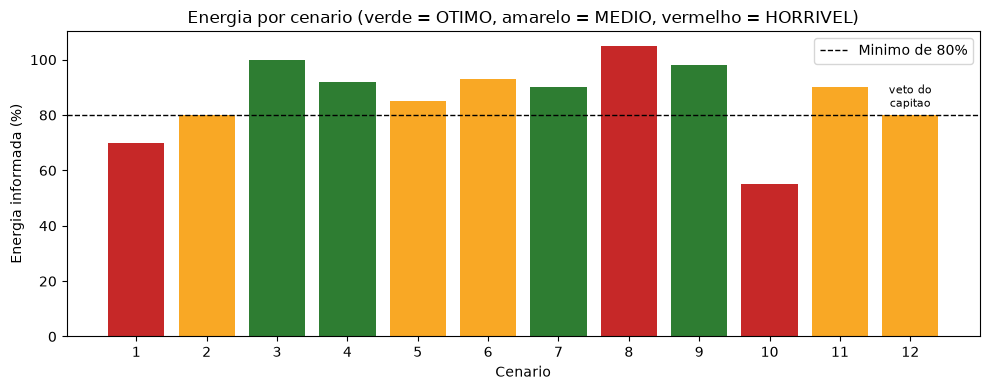

In [17]:
# GRAFICO (OPCIONAL): SO EXECUTA SE matplotlib ESTIVER INSTALADO.
# SEM A BIBLIOTECA, AS CELULAS ANTERIORES JA MOSTRARAM OS MESMOS DADOS EM TEXTO.
try:
    import matplotlib.pyplot as plt

    if registros:
        cores = {"OTIMO": "#2e7d32", "MEDIO": "#f9a825", "HORRIVEL": "#c62828"}
        execucoes = [int(r["execucao"]) for r in registros]
        energias = [float(r["energia_pct"]) for r in registros]
        cor_barras = [cores.get(r["classificacao"], "#666666") for r in registros]
        vetos = [int(r["execucao"]) for r in registros if r["classificacao"] == "MEDIO" and r["decolagem"] == "ABORTADA"]

        figura, eixo = plt.subplots(figsize=(10, 4))
        eixo.bar(execucoes, energias, color=cor_barras)
        eixo.axhline(ENERGIA_MINIMA, color="black", linestyle="--", linewidth=1, label="Minimo de {:.0f}%".format(ENERGIA_MINIMA))
        for numero in vetos:
            eixo.annotate("veto do\ncapitao", (numero, float(registros[numero - 1]["energia_pct"])),
                          textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
        eixo.set_xlabel("Cenario")
        eixo.set_ylabel("Energia informada (%)")
        eixo.set_title("Energia por cenario (verde = OTIMO, amarelo = MEDIO, vermelho = HORRIVEL)")
        eixo.set_xticks(execucoes)
        eixo.legend()
        plt.tight_layout()
        plt.show()
except ImportError:
    print("matplotlib nao instalado - grafico omitido.")
    print("Para instalar: pip install matplotlib")

### Leitura dos resultados

O cenário mais instrutivo da coleta é o **número 08**, com energia informada como
105%. As seis verificações clássicas aprovaram todos os parâmetros — afinal, 105
não é menor que 80. O sistema teria autorizado a decolagem de uma nave com um
sensor corrompido. Foi a camada de análise que barrou.

Repare na coluna de energia disponível desse cenário na planilha: **1050 kWh em uma
bateria de 1000 kWh**. É a prova numérica de que o dado era impossível — algo que
nenhuma verificação de faixa isolada conseguiria perceber, porque o valor,
sozinho, estava acima do mínimo.

O cenário **09** cumpre o papel oposto e igualmente importante: com temperatura
externa de 5°C, ele **não** dispara o alerta de frio. Isso demonstra que a regra
discrimina de fato, em vez de alertar sobre qualquer coisa.

O cenário **12** é a decisão humana em ação: energia no limiar exato de 80%, um
alerta, classificação MÉDIO, e a capitã respondeu `n`. A decolagem foi abortada e
a missão não aconteceu, com a mesma telemetria que em outro dia poderia ter sido
liberada. É o único ABORTADA da tabela que não veio nem de uma verificação nem
da IA.

---
## As missões Terra → Marte

> **Modelo energético unificado:** a missão parte da energia pós-decolagem já calculada no item 1.4 (`autonomia_restante`). As perdas de 8% e o consumo de 300 kWh são descontados uma única vez; não existe um segundo custo de decolagem na simulação.


Quando a decolagem é autorizada, o `main.py` continua para a simulação da missão:
a IA escolhe a rota pela carga da bateria (90% ou mais vai pela rota rápida;
abaixo disso, pela econômica) e simula o voo hora a hora, decidindo o estado da
nave (verde, amarelo, vermelho), ligando e desligando sistemas por prioridade e
vigiando a reserva de 30% para a volta. Se uma manobra de correção de rota cair
durante a tempestade solar, a IA a adia para a primeira hora com clima normal.

Cada missão grava uma linha em `missoes/registro_missoes.csv` e uma caixa preta
em TXT com todas as horas. A célula abaixo lê a planilha. Os números do modelo
(custos pontuais, consumo dos sistemas, recarga, reserva, fases e tempestades)
são as constantes no topo do `main.py`, cada uma comentada com a origem.

In [18]:
caminhos_possiveis = [
    os.path.join("..", "missoes", "registro_missoes.csv"),
    os.path.join("missoes", "registro_missoes.csv"),
]

arquivo_csv = None
for caminho in caminhos_possiveis:
    if os.path.exists(caminho):
        arquivo_csv = caminho
        break

if arquivo_csv is None:
    print("Planilha de missoes nao encontrada. Ela nasce na primeira decolagem autorizada.")
    missoes = []
else:
    arquivo = open(arquivo_csv, "r", encoding="utf-8-sig")
    missoes = list(csv.DictReader(arquivo, delimiter=";"))
    arquivo.close()
    print("Missoes carregadas de {}: {}".format(arquivo_csv, len(missoes)))
    print("")
    print("{:>3}  {:>7}  {:<26}  {:>5}  {:>7}  {:>7}  {:>5} {:>5} {:>5}  {:>5}  {}".format(
        "#", "ENERGIA", "ROTA", "HORAS", "FINAL", "MINIMA", "VERDE", "AMAR", "VERM", "RISCO", "STATUS"))
    print("-" * 110)
    for m in missoes:
        print("{:>3}  {:>6}%  {:<26}  {:>5}  {:>6}%  {:>6}%  {:>5} {:>5} {:>5}  {:>5}  {}".format(
            m["missao"], m["energia_inicial_pct"], m["rota"], m["horas"], m["bateria_final_pct"],
            m["bateria_minima_pct"], m["horas_verde"], m["horas_amarelo"], m["horas_vermelho"],
            m["avisos_risco"], m["status"]))

Missoes carregadas de ../missoes/registro_missoes.csv: 8

  #  ENERGIA  ROTA                        HORAS    FINAL   MINIMA  VERDE  AMAR  VERM  RISCO  STATUS
--------------------------------------------------------------------------------------------------------------
  1    80.0%  Rota Economica (Hohmann)      136     1.0%     1.0%      0     0   136      3  CONCLUIDA COM RISCO
  2   100.0%  Rota Rapida                    96     8.1%     8.1%      0    13    83      3  CONCLUIDA COM RISCO
  3    92.0%  Rota Rapida                    96     0.7%     0.7%      0    13    83      3  CONCLUIDA COM RISCO
  4    85.0%  Rota Economica (Hohmann)      136     5.6%     5.6%      0     0   136      3  CONCLUIDA COM RISCO
  5    93.0%  Rota Rapida                    96     1.7%     1.7%      0    13    83      3  CONCLUIDA COM RISCO
  6    90.0%  Rota Rapida                    90     0.0%     0.0%      0    12    78      3  FALHA
  7    98.0%  Rota Rapida                    96     6.3%     6.3%  

As **8 missões** resultam em **6 concluídas com risco e 2 falhas**. As missões
06 (cenário 07) e 08 (cenário 11) esgotam a bateria na hora 90. A aprovação da
pré-decolagem não garante o sucesso da extensão Terra → Marte. As perdas e os
300 kWh são descontados apenas uma vez.

A missão adicional vem do cenário 07: suas temperaturas, pressão e módulos
aprovam a integridade calculada. O antigo bloqueio vinha apenas do valor manual
`0`, que deixou de ser uma entrada. A coleta passa a **4 ÓTIMOS, 5 MÉDIOS e
3 HORRÍVEIS**; as cinco leituras originais foram preservadas.


---
## Como executar

**Programa interativo** (pede o nome do capitão e os dados pelo teclado, grava o
cenário e, se a decolagem for autorizada, segue para a missão Terra → Marte):

```
python scripts/main.py
```

**Este notebook**: execute as células em ordem. Só a biblioteca padrão é
necessária; o gráfico aparece se `matplotlib` estiver instalado.

## Estrutura do repositório

```
├── scripts/
│   └── main.py          O PROGRAMA: verificacao de decolagem + missao Terra -> Marte
├── cenarios/            12 cenarios coletados (CSV + TXT)
├── missoes/             8 missoes simuladas (CSV + caixa preta TXT)
└── notebook/            este notebook
```

A reflexao critica (item 1.6) esta no relatorio em PDF, entregue junto com o
link deste repositorio.